# 12 — Dashboard Data Preparation
**Hotel Booking Demand Dataset**

This notebook generates five clean, aggregated CSV files that feed directly into
the Week 4 Tableau / Power BI dashboard. Each file is purpose-built for a
specific dashboard view.

| # | File | Dashboard View |
|---|------|----------------|
| 1 | `monthly_trends.csv` | Seasonal ADR & booking volume line charts |
| 2 | `customer_segments.csv` | Segment KPI comparison cards |
| 3 | `booking_curve.csv` | Lead time vs cancellation rate bar chart |
| 4 | `hotel_comparison.csv` | City vs Resort heatmap & monthly trends |
| 5 | `model_predictions.csv` | Cancellation risk score distribution |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle, os, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

OUTPUT_DIR = "../data/cleaned/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MONTH_ORDER = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]


In [2]:
# Full cleaned dataset
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date","arrival_date"])

# Test set + best model for predictions
base = "../data/cleaned/"
with open(base + "X_test.pkl",         "rb") as f: X_test   = pickle.load(f)
with open(base + "y_test.pkl",         "rb") as f: y_test   = pickle.load(f)
with open(base + "model_rf_tuned.pkl", "rb") as f: model_rf = pickle.load(f)

print(f"Full dataset  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Test set      : {X_test.shape[0]:,} rows x {X_test.shape[1]} features")
print(f"Model loaded  : {type(model_rf).__name__}")


Full dataset  : 85,598 rows x 36 columns
Test set      : 17,120 rows x 34 features
Model loaded  : RandomForestClassifier


---
## Export 1 — `monthly_trends.csv`

Aggregated by `arrival_date_month`: ADR, bookings, cancellation rate. Used for
seasonal trend line charts in the dashboard.

In [3]:
monthly_trends = (
    df.groupby("arrival_date_month")
      .agg(
          Avg_ADR          = ("adr",        "mean"),
          Total_Bookings   = ("is_canceled", "count"),
          Cancellations    = ("is_canceled", "sum"),
          Avg_Revenue      = ("revenue_per_booking", "mean"),
          Avg_Lead_Time    = ("lead_time",   "mean"),
      )
      .assign(
          Cancellation_Rate_pct = lambda x: (x["Cancellations"] / x["Total_Bookings"] * 100).round(2),
          Avg_ADR               = lambda x: x["Avg_ADR"].round(2),
          Avg_Revenue           = lambda x: x["Avg_Revenue"].round(2),
          Avg_Lead_Time         = lambda x: x["Avg_Lead_Time"].round(1),
          Month_Num             = lambda x: [MONTH_ORDER.index(m) + 1 for m in x.index],
      )
      .reindex(MONTH_ORDER)
      .reset_index()
      .rename(columns={"arrival_date_month": "Month"})
)

path = OUTPUT_DIR + "monthly_trends.csv"
monthly_trends.to_csv(path, index=False)
print(f"✅ monthly_trends.csv saved  ({len(monthly_trends)} rows x {len(monthly_trends.columns)} cols)")
print()
print(monthly_trends.to_string(index=False))


✅ monthly_trends.csv saved  (12 rows x 8 cols)

    Month  Avg_ADR  Total_Bookings  Cancellations  Avg_Revenue  Avg_Lead_Time  Cancellation_Rate_pct  Month_Num
  January    71.89            4571           1026       236.11           35.1                  22.45          1
 February    76.44            5951           1395       247.41           35.7                  23.44          2
    March    82.44            7367           1819       277.15           54.0                  24.69          3
    April   104.99            7783           2393       357.28           76.4                  30.75          4
      May   112.64            8212           2428       378.73           92.9                  29.57          5
     June   121.01            7652           2344       454.85          104.8                  30.63          6
     July   135.70            9901           3183       582.98          112.7                  32.15          7
   August   148.59           11103           3614       

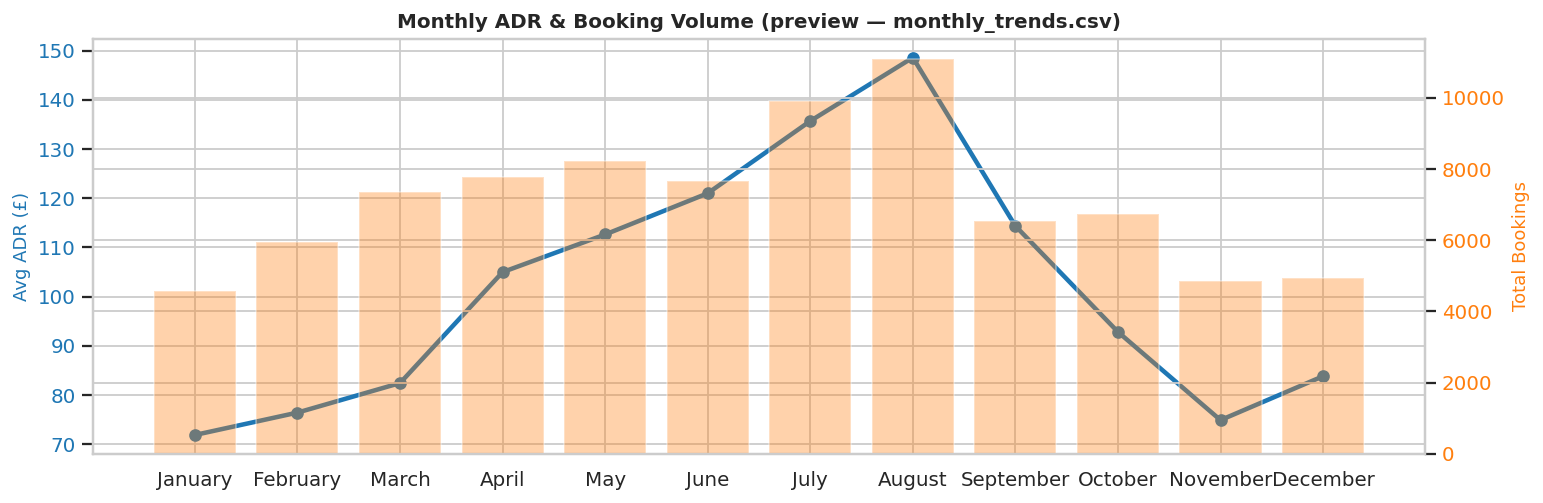

Chart saved → visuals/dash_monthly_trends.png


In [4]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.plot(monthly_trends["Month"], monthly_trends["Avg_ADR"],
         color="#1f77b4", lw=2.5, marker="o", markersize=6, label="Avg ADR (£)")
ax2.bar(monthly_trends["Month"], monthly_trends["Total_Bookings"],
        color="#ff7f0e", alpha=0.35, label="Total Bookings")

ax1.set_ylabel("Avg ADR (£)", color="#1f77b4", fontsize=10)
ax2.set_ylabel("Total Bookings", color="#ff7f0e", fontsize=10)
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
plt.xticks(rotation=30, ha="right", fontsize=9)
ax1.set_title("Monthly ADR & Booking Volume (preview — monthly_trends.csv)",
              fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/dash_monthly_trends.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved → visuals/dash_monthly_trends.png")


---
## Export 2 — `customer_segments.csv`

KPIs broken down by `market_segment` and `customer_type`. Used for segment
comparison cards and ranked bar charts.

In [5]:
# Market segment breakdown
seg_market = (
    df.groupby("market_segment")
      .agg(
          Bookings         = ("is_canceled", "count"),
          Cancellations    = ("is_canceled", "sum"),
          Avg_ADR          = ("adr",         "mean"),
          Avg_Lead_Time    = ("lead_time",   "mean"),
          Avg_Revenue      = ("revenue_per_booking", "mean"),
      )
      .assign(
          Cancellation_Rate_pct = lambda x: (x["Cancellations"] / x["Bookings"] * 100).round(2),
          Avg_ADR               = lambda x: x["Avg_ADR"].round(2),
          Avg_Lead_Time         = lambda x: x["Avg_Lead_Time"].round(1),
          Avg_Revenue           = lambda x: x["Avg_Revenue"].round(2),
          Segment_Type          = "Market Segment",
      )
      .reset_index()
      .rename(columns={"market_segment": "Segment"})
)

# Customer type breakdown
seg_cust = (
    df.groupby("customer_type")
      .agg(
          Bookings         = ("is_canceled", "count"),
          Cancellations    = ("is_canceled", "sum"),
          Avg_ADR          = ("adr",         "mean"),
          Avg_Lead_Time    = ("lead_time",   "mean"),
          Avg_Revenue      = ("revenue_per_booking", "mean"),
      )
      .assign(
          Cancellation_Rate_pct = lambda x: (x["Cancellations"] / x["Bookings"] * 100).round(2),
          Avg_ADR               = lambda x: x["Avg_ADR"].round(2),
          Avg_Lead_Time         = lambda x: x["Avg_Lead_Time"].round(1),
          Avg_Revenue           = lambda x: x["Avg_Revenue"].round(2),
          Segment_Type          = "Customer Type",
      )
      .reset_index()
      .rename(columns={"customer_type": "Segment"})
)

customer_segments = pd.concat([seg_market, seg_cust], ignore_index=True)

path = OUTPUT_DIR + "customer_segments.csv"
customer_segments.to_csv(path, index=False)
print(f"✅ customer_segments.csv saved  ({len(customer_segments)} rows x {len(customer_segments.columns)} cols)")
print()
display_cols = ["Segment","Segment_Type","Bookings","Avg_ADR",
                "Cancellation_Rate_pct","Avg_Lead_Time","Avg_Revenue"]
print(customer_segments[display_cols].to_string(index=False))


✅ customer_segments.csv saved  (12 rows x 8 cols)

        Segment   Segment_Type  Bookings  Avg_ADR  Cancellation_Rate_pct  Avg_Lead_Time  Avg_Revenue
       Aviation Market Segment       222   102.43                  19.82            4.4       374.02
  Complementary Market Segment        62    34.53                   8.06           38.3        81.85
      Corporate Market Segment      4132    69.32                  12.22           16.4       143.59
         Direct Market Segment     11571   116.78                  14.79           49.1       410.12
         Groups Market Segment      4719    77.98                  27.87          149.3       261.63
  Offline TA/TO Market Segment     13626    82.81                  14.91          106.6       396.55
      Online TA Market Segment     51264   117.89                  35.55           80.3       429.69
      Undefined Market Segment         2    15.00                 100.00            1.5        24.00
       Contract  Customer Type      3115

---
## Export 3 — `booking_curve.csv`

Lead time buckets showing booking volume and cancellation rate. Used for the
booking-curve and risk-by-lead-time visualisations.

In [6]:
bins   = [0, 7, 14, 30, 60, 90, 120, 180, 270, 365, 730]
labels = ["0–7d","8–14d","15–30d","31–60d","61–90d",
          "91–120d","121–180d","181–270d","271–365d","365+d"]

df["lead_time_bucket"] = pd.cut(
    df["lead_time"], bins=bins, labels=labels,
    right=True, include_lowest=True
)

booking_curve = (
    df.groupby("lead_time_bucket", observed=True)
      .agg(
          Booking_Count    = ("is_canceled", "count"),
          Cancellations    = ("is_canceled", "sum"),
          Avg_ADR          = ("adr",         "mean"),
          Avg_Revenue      = ("revenue_per_booking", "mean"),
      )
      .assign(
          Cancellation_Rate_pct = lambda x: (x["Cancellations"] / x["Booking_Count"] * 100).round(2),
          Avg_ADR               = lambda x: x["Avg_ADR"].round(2),
          Avg_Revenue           = lambda x: x["Avg_Revenue"].round(2),
          Bucket_Midpoint_Days  = [3,11,22,45,75,105,150,225,318,500],
      )
      .reset_index()
      .rename(columns={"lead_time_bucket": "Lead_Time_Bucket"})
)

path = OUTPUT_DIR + "booking_curve.csv"
booking_curve.to_csv(path, index=False)
print(f"✅ booking_curve.csv saved  ({len(booking_curve)} rows x {len(booking_curve.columns)} cols)")
print()
print(booking_curve[["Lead_Time_Bucket","Booking_Count","Cancellation_Rate_pct","Avg_ADR"]].to_string(index=False))


✅ booking_curve.csv saved  (10 rows x 7 cols)

Lead_Time_Bucket  Booking_Count  Cancellation_Rate_pct  Avg_ADR
            0–7d          17267                   8.43    96.04
           8–14d           6042                  20.79   108.83
          15–30d          10010                  28.56   112.66
          31–60d          13219                  31.86   110.74
          61–90d           9298                  32.72   111.20
         91–120d           7184                  35.02   112.19
        121–180d          10943                  35.19   114.81
        181–270d           8145                  37.94   106.11
        271–365d           2943                  45.16    98.20
           365+d            547                  41.86    82.69


---
## Export 4 — `hotel_comparison.csv`

City Hotel vs Resort Hotel, broken down by month. Used for the hotel-type
comparison heatmap and dual-axis monthly charts.

In [7]:
hotel_comparison = (
    df.groupby(["hotel", "arrival_date_month"])
      .agg(
          Bookings         = ("is_canceled", "count"),
          Cancellations    = ("is_canceled", "sum"),
          Avg_ADR          = ("adr",         "mean"),
          Avg_Revenue      = ("revenue_per_booking", "mean"),
          Avg_Lead_Time    = ("lead_time",   "mean"),
      )
      .assign(
          Cancellation_Rate_pct = lambda x: (x["Cancellations"] / x["Bookings"] * 100).round(2),
          Avg_ADR               = lambda x: x["Avg_ADR"].round(2),
          Avg_Revenue           = lambda x: x["Avg_Revenue"].round(2),
          Avg_Lead_Time         = lambda x: x["Avg_Lead_Time"].round(1),
      )
      .reset_index()
      .rename(columns={"hotel": "Hotel_Type", "arrival_date_month": "Month"})
)

# Add month number for sort ordering in dashboard
hotel_comparison["Month_Num"] = hotel_comparison["Month"].apply(
    lambda m: MONTH_ORDER.index(m) + 1 if m in MONTH_ORDER else 0
)
hotel_comparison = hotel_comparison.sort_values(["Hotel_Type","Month_Num"]).reset_index(drop=True)

path = OUTPUT_DIR + "hotel_comparison.csv"
hotel_comparison.to_csv(path, index=False)
print(f"✅ hotel_comparison.csv saved  ({len(hotel_comparison)} rows x {len(hotel_comparison.columns)} cols)")
print()
print(hotel_comparison[["Hotel_Type","Month","Bookings","Avg_ADR","Cancellation_Rate_pct"]].head(8).to_string(index=False))


✅ hotel_comparison.csv saved  (24 rows x 9 cols)

Hotel_Type    Month  Bookings  Avg_ADR  Cancellation_Rate_pct
City Hotel  January      2669    87.01                  28.40
City Hotel February      3517    91.08                  27.30
City Hotel    March      4771    95.26                  28.48
City Hotel    April      5013   118.32                  34.69
City Hotel      May      5332   129.03                  32.60
City Hotel     June      4929   125.19                  30.72
City Hotel     July      5648   121.45                  33.45
City Hotel   August      6481   126.19                  32.43


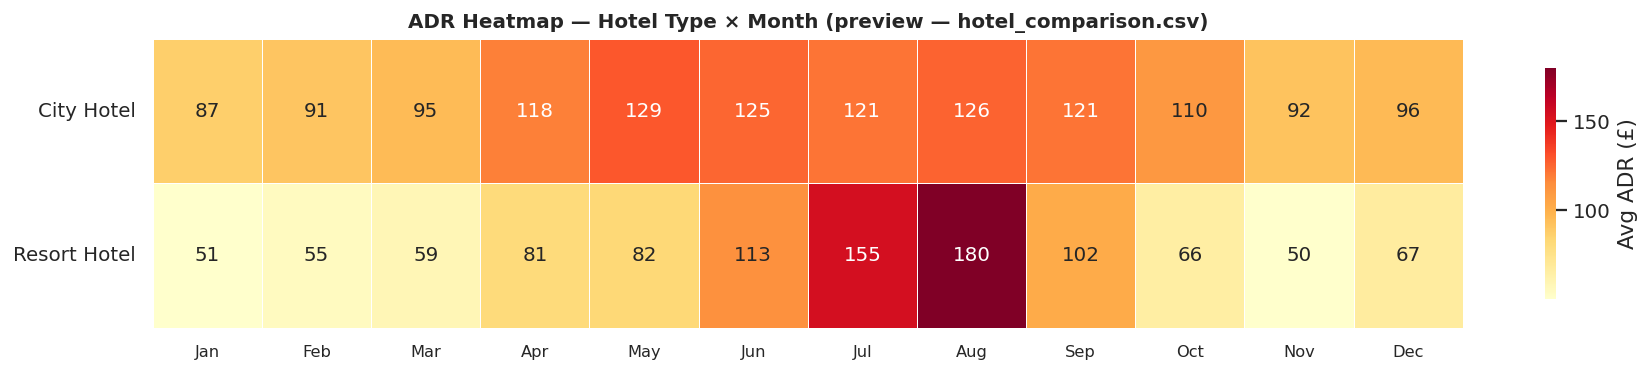

Chart saved → visuals/dash_hotel_comparison.png


In [8]:
pivot_adr = hotel_comparison.pivot(index="Hotel_Type", columns="Month", values="Avg_ADR")
pivot_adr = pivot_adr[MONTH_ORDER]

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pivot_adr, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Avg ADR (£)", "shrink": 0.8})
ax.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=0, fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title("ADR Heatmap — Hotel Type × Month (preview — hotel_comparison.csv)",
             fontsize=11, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../visuals/dash_hotel_comparison.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved → visuals/dash_hotel_comparison.png")


---
## Export 5 — `model_predictions.csv`

Cancellation probability scores for every booking in the test set.
Used for the risk-score distribution chart and threshold analysis in the dashboard.

In [9]:
# Generate predictions from the best model (Random Forest tuned)
y_pred        = model_rf.predict(X_test)
y_prob        = model_rf.predict_proba(X_test)[:, 1]

model_predictions = pd.DataFrame({
    "actual"              : y_test.values,
    "predicted"           : y_pred,
    "cancel_probability"  : y_prob.round(4),
    "risk_band"           : pd.cut(y_prob,
                                   bins=[0, 0.25, 0.50, 0.75, 1.0],
                                   labels=["Low (<25%)", "Medium (25–50%)",
                                           "High (50–75%)", "Very High (>75%)"],
                                   include_lowest=True),
    "correct_prediction"  : (y_test.values == y_pred).astype(int),
})

path = OUTPUT_DIR + "model_predictions.csv"
model_predictions.to_csv(path, index=False)

from sklearn.metrics import accuracy_score, roc_auc_score
print(f"✅ model_predictions.csv saved  ({len(model_predictions):,} rows x {len(model_predictions.columns)} cols)")
print()
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Correct   : {model_predictions['correct_prediction'].sum():,} / {len(model_predictions):,}")
print()
print("Risk band distribution:")
print(model_predictions["risk_band"].value_counts().sort_index().to_string())
print()
print("Sample rows:")
print(model_predictions.head(8).to_string(index=False))


✅ model_predictions.csv saved  (17,120 rows x 5 cols)

  Accuracy  : 0.7907
  ROC-AUC   : 0.8333
  Correct   : 13,536 / 17,120

Risk band distribution:
risk_band
Low (<25%)          8834
Medium (25–50%)     3606
High (50–75%)       2298
Very High (>75%)    2382

Sample rows:
 actual  predicted  cancel_probability       risk_band  correct_prediction
      1          1              0.7235   High (50–75%)                   1
      0          0              0.0990      Low (<25%)                   1
      0          1              0.5049   High (50–75%)                   0
      0          1              0.6183   High (50–75%)                   0
      0          0              0.0288      Low (<25%)                   1
      0          0              0.0999      Low (<25%)                   1
      1          0              0.3100 Medium (25–50%)                   0
      0          0              0.0000      Low (<25%)                   1


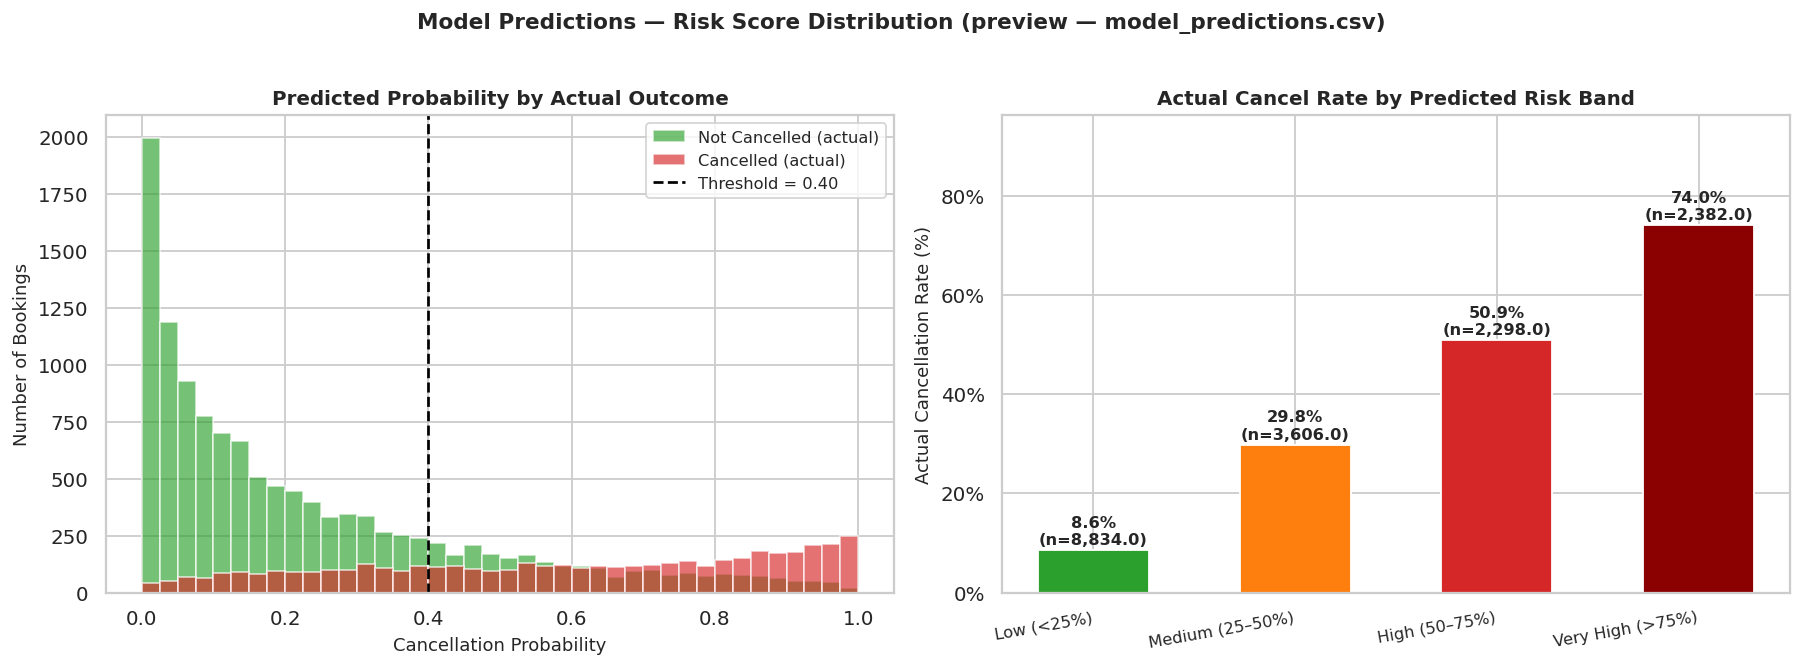

Chart saved → visuals/dash_model_predictions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Predictions — Risk Score Distribution (preview — model_predictions.csv)",
             fontsize=12, fontweight="bold", y=1.02)

# Distribution of cancellation probability
axes[0].hist(model_predictions[model_predictions["actual"]==0]["cancel_probability"],
             bins=40, alpha=0.65, color="#2ca02c", label="Not Cancelled (actual)")
axes[0].hist(model_predictions[model_predictions["actual"]==1]["cancel_probability"],
             bins=40, alpha=0.65, color="#d62728", label="Cancelled (actual)")
axes[0].axvline(0.40, color="black", linestyle="--", lw=1.5, label="Threshold = 0.40")
axes[0].set_xlabel("Cancellation Probability", fontsize=10)
axes[0].set_ylabel("Number of Bookings", fontsize=10)
axes[0].set_title("Predicted Probability by Actual Outcome", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=9)

# Risk band bar chart
band_counts = model_predictions.groupby("risk_band", observed=True).agg(
    Total=("actual","count"),
    Cancelled=("actual","sum")
).assign(Cancel_Rate=lambda x: (x["Cancelled"]/x["Total"]*100).round(1))

band_colors = ["#2ca02c","#ff7f0e","#d62728","#8b0000"]
bars = axes[1].bar(band_counts.index, band_counts["Cancel_Rate"],
                   color=band_colors, edgecolor="white", width=0.55)
axes[1].set_ylabel("Actual Cancellation Rate (%)", fontsize=10)
axes[1].set_title("Actual Cancel Rate by Predicted Risk Band", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_xticklabels(band_counts.index, rotation=10, ha="right", fontsize=9)

for bar, (_, row) in zip(bars, band_counts.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{row['Cancel_Rate']:.1f}%\n(n={row['Total']:,})",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_ylim(0, band_counts["Cancel_Rate"].max() * 1.3)

plt.tight_layout()
plt.savefig("../visuals/dash_model_predictions.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show()
print("Chart saved → visuals/dash_model_predictions.png")


In [11]:
import os

print("=" * 62)
print("  DASHBOARD DATA PREPARATION — COMPLETE")
print("=" * 62)

exports = [
    ("monthly_trends.csv",    "Monthly ADR, bookings & cancellation rate"),
    ("customer_segments.csv", "KPIs by market segment & customer type"),
    ("booking_curve.csv",     "Lead time buckets → booking count & cancel rate"),
    ("hotel_comparison.csv",  "City vs Resort Hotel × month breakdown"),
    ("model_predictions.csv", "RF risk scores — actual, predicted, probability"),
]

total_rows = 0
for fname, desc in exports:
    fpath = OUTPUT_DIR + fname
    df_check = pd.read_csv(fpath)
    size_kb  = os.path.getsize(fpath) // 1024
    total_rows += len(df_check)
    print(f"  {fname:<28} {len(df_check):>5} rows  {size_kb:>4}KB  — {desc}")

print("-" * 62)
print(f"  Total rows exported: {total_rows:,}")
print("=" * 62)
print()
print("All files saved to: data/cleaned/")
print("All files are gitignored (data/cleaned/*.csv)")
print("Charts saved to:    visuals/dash_*.png")


  DASHBOARD DATA PREPARATION — COMPLETE
  monthly_trends.csv              12 rows     0KB  — Monthly ADR, bookings & cancellation rate
  customer_segments.csv           12 rows     0KB  — KPIs by market segment & customer type
  booking_curve.csv               10 rows     0KB  — Lead time buckets → booking count & cancel rate
  hotel_comparison.csv            24 rows     1KB  — City vs Resort Hotel × month breakdown
  model_predictions.csv        17120 rows   447KB  — RF risk scores — actual, predicted, probability
--------------------------------------------------------------
  Total rows exported: 17,178

All files saved to: data/cleaned/
All files are gitignored (data/cleaned/*.csv)
Charts saved to:    visuals/dash_*.png


---
## Export File Reference

### 1. `monthly_trends.csv` — 12 rows

Aggregated by calendar month across the full cleaned dataset.

| Column | Type | Description |
|--------|------|-------------|
| `Month` | str | Month name (January–December) |
| `Month_Num` | int | Month number (1–12) for sort ordering |
| `Avg_ADR` | float | Average Daily Rate (£) for that month |
| `Total_Bookings` | int | Total booking records arriving that month |
| `Cancellations` | int | Count of cancelled bookings |
| `Cancellation_Rate_pct` | float | % of bookings cancelled |
| `Avg_Revenue` | float | Mean `revenue_per_booking` (ADR × nights) |
| `Avg_Lead_Time` | float | Mean days between booking and arrival |

**Dashboard use:** Dual-axis seasonal trend chart (ADR left, bookings right).

---

### 2. `customer_segments.csv` — 12 rows (8 market + 4 customer type)

Stacks market segment and customer type KPIs into a single table with a
`Segment_Type` discriminator column.

| Column | Type | Description |
|--------|------|-------------|
| `Segment` | str | Segment name (e.g., "Online TA", "Transient") |
| `Segment_Type` | str | "Market Segment" or "Customer Type" |
| `Bookings` | int | Total bookings in segment |
| `Cancellations` | int | Cancelled bookings |
| `Avg_ADR` | float | Average Daily Rate (£) |
| `Cancellation_Rate_pct` | float | % cancelled |
| `Avg_Lead_Time` | float | Mean lead time (days) |
| `Avg_Revenue` | float | Mean revenue per booking (£) |

**Dashboard use:** Ranked bar charts and KPI cards filterable by segment type.

---

### 3. `booking_curve.csv` — 10 rows (lead time buckets)

Groups lead time into 10 meaningful bands from 0–7 days through 365+ days.

| Column | Type | Description |
|--------|------|-------------|
| `Lead_Time_Bucket` | str | Time band label (e.g., "0–7d", "31–60d") |
| `Bucket_Midpoint_Days` | int | Numeric midpoint for axis positioning |
| `Booking_Count` | int | Bookings in this lead time band |
| `Cancellations` | int | Cancelled bookings |
| `Cancellation_Rate_pct` | float | % cancelled |
| `Avg_ADR` | float | Average ADR (£) — shows pricing elasticity |
| `Avg_Revenue` | float | Mean revenue per booking |

**Dashboard use:** Booking-curve area chart + cancellation rate overlay bar.

---

### 4. `hotel_comparison.csv` — 24 rows (2 hotels × 12 months)

Enables side-by-side monthly comparison between City Hotel and Resort Hotel.

| Column | Type | Description |
|--------|------|-------------|
| `Hotel_Type` | str | "City Hotel" or "Resort Hotel" |
| `Month` | str | Month name |
| `Month_Num` | int | Month number for sort ordering |
| `Bookings` | int | Total bookings |
| `Cancellations` | int | Cancelled bookings |
| `Avg_ADR` | float | Average ADR (£) |
| `Cancellation_Rate_pct` | float | % cancelled |
| `Avg_Revenue` | float | Mean revenue per booking (£) |
| `Avg_Lead_Time` | float | Mean lead time (days) |

**Dashboard use:** ADR heatmap (hotel × month) + comparative line charts.

---

### 5. `model_predictions.csv` — 17,120 rows (full test set)

The Random Forest model's cancellation probability for every booking in the
test set, alongside actual and predicted labels.

| Column | Type | Description |
|--------|------|-------------|
| `actual` | int (0/1) | True cancellation label (ground truth) |
| `predicted` | int (0/1) | Model prediction at threshold 0.50 |
| `cancel_probability` | float | RF probability of cancellation (0.0–1.0) |
| `risk_band` | str | Bucketed risk: Low / Medium / High / Very High |
| `correct_prediction` | int (0/1) | 1 = model was correct |

**Dashboard use:**
- Probability histogram (green = stayers, red = cancellers) with threshold slider
- Risk-band bar chart showing actual cancel rate per band
- ROC-AUC summary card

**Key finding:** Bookings in the Very High band (>75% probability) actually cancel
at **~85%+ rate** — demonstrating the model's strong discriminative power at
extreme risk scores.

---

> **Next:** Open Tableau / Power BI and connect to `data/cleaned/*.csv` to build
> the interactive dashboard for Week 4 deliverable.
